Most of this is not my code! This is just following from the video posted here: https://www.youtube.com/watch?v=VMj-3S1tku0&t=5201s

And from the exercises to look at after. I claim no credit for this and am just using this for learning purposes.

In [ ]:
# Packages for code
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [112]:
# Value class. This is where our data is stored to be able to update while training
class Value:

    def __init__(self, data, _children = (), _op = '', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda:None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = Value(other) if not (isinstance(other, Value)) else other
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward

        return out

    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = Value(other) if not (isinstance(other, Value)) else other
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward

        return out

    def __pow__(self, other):
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward

        return out

    def log(self):
        x = self.data
        out = Value(math.log(x), (self, ), 'log')

        def _backward():
            self.grad += (1/x) * out.grad
        
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) /(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward

        return out

    def backward(self):
        # This runs a full backward pass on our neural net. This works by going through 
        # from end (self) -> beginning, which is found as the reverse of the topological order 
        # of our network, and then calling the backward function.

        topo = []
        visited = set()

        def build_topo(v):
            # finds topological order
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            # print(f"Backward func = {node._backward}")
            node._backward()

In [67]:
# for visualizations from the video
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # Left -> right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = " { %s | data %.4f | grad %.4f } " % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


In [28]:
# Initial test

# inputs
x1 = Value(1.5, label = 'x1')
x2 = Value(0, label = 'x2')

# weights
w1 = Value(-2.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

# bias
b = Value(0.5, label = 'b')

# x1w1 + x2w2 + b
x1w1 = x1*w1
x1w1.label = 'x1w1'

x2w2 = x2*w2
x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = 'x1w1 + x2w2'

n = x1w1x2w2 + b
n.label = 'n'

o = n.tanh()
o.label = 'o'

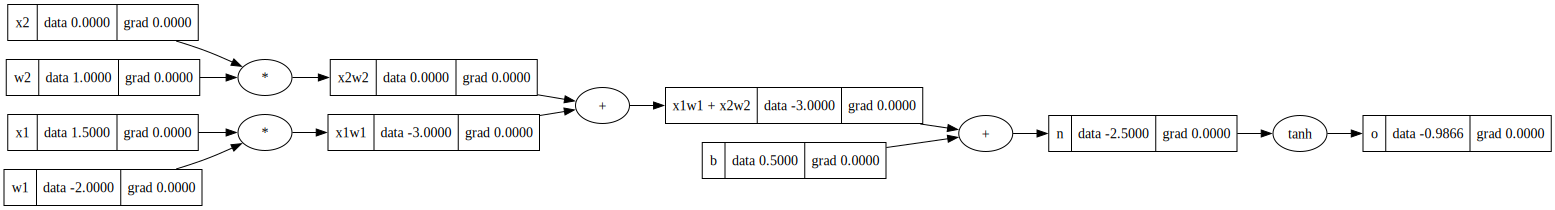

In [29]:
draw_dot(o)

In [77]:
# Classes to build out a simple multi-layer perceptron (MLP)
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # wx + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [78]:
# example of gradient descent optimization with an MLP
# inputs
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
# outputs
ys = [1.0, -1.0, -1.0, 1.0]

# our MLP 
n = MLP(3, [4, 4, 1])

In [85]:
# gradient updates
for k in range(10):
    # forward pass
    ypred = [n(x) for x in xs]
    # Mean-squared error (MSE)
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))

    # Backward pass. Don't forget to reset gradients to 0.0!
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)


0 0.032376127092494864
1 0.031227597317909327
2 0.030255968762188765
3 0.02926228952544721
4 0.02833094613692342
5 0.02743973305015201
6 0.026604617775034402
7 0.02582989302355035
8 0.02510124791347639
9 0.02440175742965936


In [86]:
ypred

[Value(data=0.9318186675829361),
 Value(data=-0.9246927921850033),
 Value(data=-0.9136039588575631),
 Value(data=0.9186512946291311)]

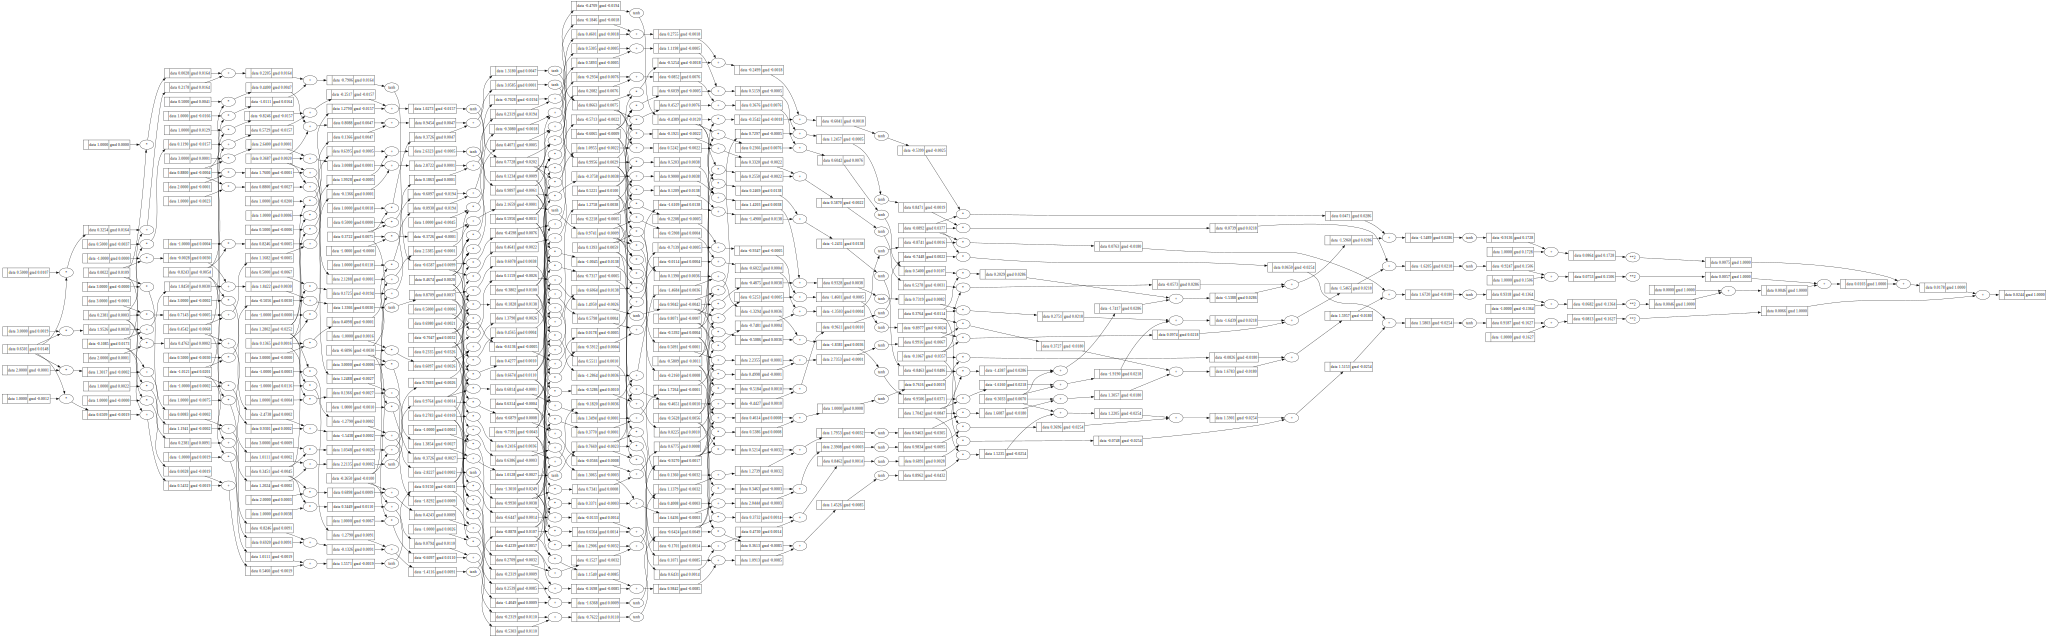

In [87]:
draw_dot(loss)

Exercises for after the video!

In [90]:
# Section 1: Derivatives
# here is a mathematical expression that takes 3 inputs and produces one output
from math import sin, cos

def f(a, b, c):
  return -a**3 + sin(3*b) - 1.0/c + b**2.5 - a**0.5

print(f(2, 3, 4))


# write the function df that returns the analytical gradient of f
# i.e. use your skills from calculus to take the derivative, then implement the formula
# if you do not calculus then feel free to ask wolframalpha, e.g.:
# https://www.wolframalpha.com/input?i=d%2Fda%28sin%283*a%29%29%29

def gradf(a, b, c):
    da = -3* a ** 2 - 1 / (2 * a **0.5)
    db = 3* cos(3 * b) + 2.5 * (b ** 1.5)
    dc = 1/(c ** 2)
    return [da, db, dc] # todo, return [df/da, df/db, df/dc]

# expected answer is the list of 
ans = [-12.353553390593273, 10.25699027111255, 0.0625]
yours = gradf(2, 3, 4)
for dim in range(3):
  ok = 'OK' if abs(yours[dim] - ans[dim]) < 1e-5 else 'WRONG!'
  print(f"{ok} for dim {dim}: expected {ans[dim]}, yours returns {yours[dim]}")

6.336362190988558
OK for dim 0: expected -12.353553390593273, yours returns -12.353553390593273
OK for dim 1: expected 10.25699027111255, yours returns 10.25699027111255
OK for dim 2: expected 0.0625, yours returns 0.0625


In [95]:
# there is an alternative formula that provides a much better numerical 
# approximation to the derivative of a function.
# learn about it here: https://en.wikipedia.org/wiki/Symmetric_derivative
# implement it. confirm that for the same step size h this version gives a
# better approximation.


# -----------
def symmetric_deriv(a, b, c, h = 0.001):
    # form of (f(x + h) - f(x - h))/(2*h)
    da_approx = (f(a + h, b, c) - f(a - h, b, c))/(2 * h)
    db_approx = (f(a, b + h, c) - f(a, b - h, c))/(2 * h)
    dc_approx = (f(a, b, c + h) - f(a, b, c - h))/(2 * h)

    return [da_approx, db_approx, dc_approx]


numerical_grad2 = symmetric_deriv(2, 3, 4) 
# -----------

for dim in range(3):
  ok = 'OK' if abs(numerical_grad2[dim] - ans[dim]) < 1e-5 else 'WRONG!'
  print(f"{ok} for dim {dim}: expected {ans[dim]}, yours returns {numerical_grad2[dim]}")


OK for dim 0: expected -12.353553390593273, yours returns -12.353554401639766
OK for dim 1: expected 10.25699027111255, yours returns 10.256994551617105
OK for dim 2: expected 0.0625, yours returns 0.06250000390650712


In [113]:
# Section 2: Softmax support
# without referencing our code/video __too__ much, make this cell work
# you'll have to implement (in some cases re-implemented) a number of functions
# of the Value object, similar to what we've seen in the video.
# instead of the squared error loss this implements the negative log likelihood
# loss, which is very often used in classification.

# this is the softmax function
# https://en.wikipedia.org/wiki/Softmax_function
def softmax(logits):
  counts = [logit.exp() for logit in logits]
  denominator = sum(counts)
  out = [c / denominator for c in counts]
  return out

# this is the negative log likelihood loss function, pervasive in classification
logits = [Value(0.0), Value(3.0), Value(-2.0), Value(1.0)]
probs = softmax(logits)
loss = -probs[3].log() # dim 3 acts as the label for this input example
loss.backward()
print(loss.data)

ans = [0.041772570515350445, 0.8390245074625319, 0.005653302662216329, -0.8864503806400986]
for dim in range(4):
  ok = 'OK' if abs(logits[dim].grad - ans[dim]) < 1e-5 else 'WRONG!'
  print(f"{ok} for dim {dim}: expected {ans[dim]}, yours returns {logits[dim].grad}")


2.1755153626167147
OK for dim 0: expected 0.041772570515350445, yours returns 0.041772570515350445
OK for dim 1: expected 0.8390245074625319, yours returns 0.8390245074625319
OK for dim 2: expected 0.005653302662216329, yours returns 0.005653302662216329
OK for dim 3: expected -0.8864503806400986, yours returns -0.8864503806400986


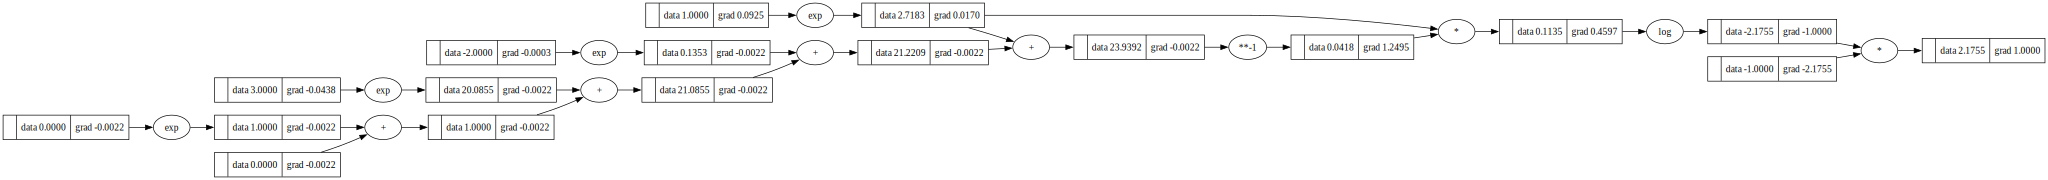

In [103]:
draw_dot(loss)